In [ ]:
import sys
import json

general = {'use_road_network': True, 'n_clusters_voronoi': 250, 'plot_ODs': True, 'transfer_penalty': 600}
footpaths = {'max_length': 1000, 'speed': 4.5, 'n_ntlegs': 10}
pathfinder_params = {'start_time': '05:00:00', 'end_time': '08:00:00', 'min_transfer_time': 30, 'cutoff': 3600}

params = {'footpaths': footpaths, 'general': general, 'pathfinder params (timetables)': pathfinder_params}

default = {'training_folder': '../../', 'scenario': 'noumea_with_timetable_bug', 'params': params, 'period': 'am'}
manual, argv = (True, default) if 'ipykernel' in sys.argv[0] else (False, dict(default, **json.loads(sys.argv[1])))
print(argv)

{'training_folder': '../../', 'scenario': 'noumea_with_timetable_bug', 'params': {'footpaths': {'max_length': 1000, 'speed': 4.5, 'n_ntlegs': 10}, 'general': {'use_road_network': True, 'n_clusters_voronoi': 250, 'plot_ODs': True, 'transfer_penalty': 0}, 'pathfinder params (timetables)': {'start_time': '05:00:00', 'end_time': '08:00:00', 'min_transfer_time': 30, 'cutoff': 0}}, 'period': 'am'}


In [206]:
import os
import geopandas as gpd
import pandas as pd
import polars as pl
import numpy as np
from datetime import datetime
import tqdm

sys.path.insert(0, r'../../../quetzal')  # Add path to quetzal
from shapely.geometry import Point, LineString
from shapely import union_all
from quetzal.model import stepmodel, connectionscanmodel
from quetzal.io.quenedi import read_parameters, restrict_df_to_variant
from syspy.spatial.utils import get_epsg
from syspy.spatial.spatial import DBSCAN_sclustering, voronoi_diagram_dataframes, zone_clusters, get_links_hull


on_lambda = bool(os.environ.get('AWS_EXECUTION_ENV'))
num_cores = os.cpu_count()
print('num cores:', num_cores, 'on_lambda:', on_lambda)

num cores: 16 on_lambda: False


# Folders stucture and params

everything is on S3 (nothing on ECR) so no direct input folder. just scenarios/{scen}/inputs/

In [207]:
scenario = argv['scenario']
training_folder = argv['training_folder']

# if local. add the path to the scenario scenarios/<scenario>/
local_scen_path = '' if on_lambda else os.path.join('scenarios/', scenario)

input_folder = os.path.join(training_folder, 'inputs/')
scenario_folder = os.path.join(training_folder, local_scen_path, 'inputs/')
model_folder = os.path.join(training_folder, local_scen_path, 'model/')
output_folder = os.path.join(training_folder, local_scen_path, 'outputs/')

if not os.path.exists(output_folder):
    os.makedirs(output_folder)

print('input folder: ', scenario_folder)
print('output folder: ', output_folder)

input folder:  ../../scenarios/noumea_with_timetable_bug\inputs/
output folder:  ../../scenarios/noumea_with_timetable_bug\outputs/


In [208]:
params = read_parameters(argv['params'])#, period=period)

rnodes_file = os.path.join(scenario_folder, 'road/road_nodes.geojson')
rnodes_file_provided = os.path.isfile(rnodes_file)

zonage_file = os.path.join(scenario_folder, 'zonage.geojson')
zonage_file_provided = os.path.isfile(zonage_file)

od_file = os.path.join(scenario_folder, 'od/od.geojson')
od_file_provided = os.path.isfile(od_file)

# inputs

In [209]:
model = connectionscanmodel.read_zippedpickles(model_folder + 'cleaned')

zones: 100%|██████████| 15/15 [00:00<00:00, 231.58it/s]


In [210]:
if not model.timetable_used:
    end_of_notebook

In [211]:
max_length = float(params['footpaths'].get('max_length', footpaths['max_length']))
speed = float(params['footpaths'].get('speed', footpaths['speed']))
n_ntlegs = int(params['footpaths'].get('n_ntlegs', footpaths['n_ntlegs']))
use_road_network = params['general'].get('use_road_network', general['use_road_network'])
n_clusters_voronoi = int(params['general'].get('n_clusters_voronoi', general['n_clusters_voronoi']))
plot_ODs = params['general'].get('plot_ODs', general['plot_ODs'])
transfer_penalty = params['general'].get('transfer_penalty', general['transfer_penalty'])

if 'pathfinder params (timetables)' not in argv['params']:
    print(" /!\ Params json is out of date /!\ ")
pathfinder_params = argv['params'].get('pathfinder params (timetables)', pathfinder_params)

start_time = pathfinder_params['start_time']
end_time = pathfinder_params['end_time']
min_transfer_time = pathfinder_params['min_transfer_time']
cutoff = pathfinder_params['cutoff']

In [212]:
walk_on_road = (rnodes_file_provided & use_road_network)

if walk_on_road:
    model.integrity_fix_road_nodeset_consistency()
    model.integrity_fix_road_network()
    model.integrity_fix_road_duplicated_ab_links()

direct: 5814it [00:00, 24550.52it/s]
reversed: 5814it [00:00, 29578.19it/s]
5814it [00:00, 28922.39it/s]


In [213]:
print('rnodes_file_provided?', rnodes_file_provided)
print('zonage_file_provided?', zonage_file_provided)
print('od_file_provided?', od_file_provided)

print('walk_on_road?', walk_on_road)

rnodes_file_provided? True
zonage_file_provided? True
od_file_provided? True
walk_on_road? True


In [214]:
crs = model.crs
crs

32758

# Preparation

In [215]:
def time_seconds(time_str):
    time_obj = datetime.strptime(time_str, '%H:%M:%S')
    return time_obj.hour * 3600 + time_obj.minute * 60 + time_obj.second

def seconds_time(total_seconds):
    total_seconds = int(total_seconds) % (24 * 3600)
    h = total_seconds // 3600
    m = (total_seconds % 3600) // 60
    #s = total_seconds % 60
    return f"{h:02d}:{m:02d}"#:{s:02d}"

In [216]:
start_time = time_seconds(start_time)
end_time = time_seconds(end_time)

In [217]:
links_with_times = model.links[['trip_id', 'a', 'b', 'departures', 'arrivals']].explode(['departures', 'arrivals'])
links_with_times = links_with_times.rename(columns={'departures':'departure_time', 'arrivals': 'arrival_time'})
links_with_times['journey'] = links_with_times.groupby(['trip_id', 'a', 'b']).cumcount() + 1

In [218]:
model.links = model.links.drop(columns=['departures', 'arrivals'])
model.links = model.links.merge(links_with_times[['departure_time', 'arrival_time', 'journey']], left_index=True, right_index=True, how='right')

In [219]:
model.links['departure_time'] = model.links['departure_time'].apply(time_seconds)
model.links['arrival_time'] = model.links['arrival_time'].apply(time_seconds)

In [220]:
model.links['trip_id'] = model.links['trip_id'] + '_' + model.links['journey'].astype(str)
model.links.drop(columns='journey', inplace=True)

In [221]:
model.links.sort_values(['trip_id', 'departure_time'], inplace=True)
model.links = model.links.reset_index(drop=True)
n_digits = len(str(len(model.links)))
model.links['prep_index'] = model.links.reset_index()['index'].apply(lambda x: ''.join(['0' for i in range(n_digits - len(str(x)))]) + str(x))

model.links.index = 'link_' + model.links['prep_index']
model.links.index.name = 'index'

In [222]:
model.links = model.links.loc[(model.links['departure_time']>(start_time - cutoff)) & (model.links['arrival_time']<(end_time + cutoff))]
model.nodes = model.nodes.loc[list(set(model.links['a'].values.tolist() + model.links['b'].values.tolist()))]

In [223]:
# clustering and rename nodes
nodes_metadata = model.nodes.copy()
model.preparation_clusterize_nodes(distance_threshold=50, fast=True, prefix='cnode_')  # modèle déjà configuré en crs métrique.
model.nodes.index.name = 'index'

can not add prefixes on table:  footpaths


# Isochrone

Use voronoi method to clusterize nodes to perform isochrone algorithm
If no zonage is provided, isochrone uses the voronoi zonage for the display
If a zonage was provided, isochrone will be projected onto this zonage (polars mega merge en deux fois arrivee puis depart) (à vol d'oiseau pour commencer, puis on le fera avec le réseau routier)

In [224]:
# clustering and rename nodes
model_iso = model.copy()
model_iso.preparation_clusterize_nodes(distance_threshold=10, fast=True, prefix='cnode_')  # modèle déjà configuré en crs métrique.
model_iso.nodes.index.name = 'index'

can not add prefixes on table:  footpaths


In [225]:
# get envelope to clip the voronoi
clip_geometry = get_links_hull(model_iso.links, tolerance=max_length)

In [226]:
# 1) Clusterize nodes that are really close
clustered_nodes = model_iso.nodes.copy()
label = DBSCAN_sclustering(clustered_nodes, distance_threshold=10)
label = 'node_cluster_' + label.astype(str)
clustered_nodes['cluster'] = label
nodes_cluster_series = clustered_nodes['cluster']

clustered_nodes = clustered_nodes.drop_duplicates('cluster')
clustered_nodes = clustered_nodes.reset_index().set_index('cluster')

In [227]:
# 2) create a voronoi with nodes clusters
voronoi, _ = voronoi_diagram_dataframes(clustered_nodes['geometry'])
voronoi.crs = crs

voronoi = voronoi.clip(clip_geometry)

In [228]:
# 3) Clusterize the voronoi into 500 zones
clusters, cluster_series = zone_clusters(voronoi, n_clusters=n_clusters_voronoi, geo_join_method=union_all)
clusters = gpd.GeoDataFrame(clusters)

cluster_series = 'zones_' + cluster_series.astype(str)
clusters.index = 'zones_' + clusters.index.astype(str)
clusters.index.name = 'index'

In [229]:
zone_cluster_dict = cluster_series.reset_index().groupby('cluster')['index'].agg(list).to_dict()
clusters['node_cluster_list'] = clusters.index.map(zone_cluster_dict.get)
clusters['node_cluster_id'] = clusters['node_cluster_list'].apply(lambda x: x[0])

In [230]:
node_cluster_dict = nodes_cluster_series.reset_index().groupby('cluster')['index'].agg(list).to_dict()
clusters['node_list'] = clusters['node_cluster_list'].apply(lambda x: [*map(node_cluster_dict.get, x)])
clusters['node_list'] = clusters['node_list'].apply(lambda ls: [item for sublist in ls for item in sublist])  # flatten
clusters['node_id'] = clusters['node_list'].apply(lambda x: x[0])

### pathfinder

In [231]:
zones = model_iso.nodes.loc[clusters['node_id'].values].copy()
zones = zones.reset_index().rename(columns={'index': 'node_id'})
zone_node_dict = clusters.reset_index().set_index('node_id')['index'].to_dict()

zones.index = zones['node_id'].apply(zone_node_dict.get)
zones.index.name = 'index'

In [232]:
model_iso.zones = zones.copy()

In [233]:
model_iso.preparation_footpaths(speed=speed, max_length=max_length)
model_iso.footpaths = model_iso.footpaths.drop(columns='voronoi')
model_iso.footpaths['speed'] = model_iso.footpaths['length'] / model_iso.footpaths['time'] * 3.6
model_iso.footpaths['duration'] = model_iso.footpaths['time']

if walk_on_road:
    sm_footpaths = stepmodel.StepModel(crs=model.crs, coordinates_unit='meter')

    sm_footpaths.road_links = model_iso.road_links.copy()
    sm_footpaths.road_links['time'] = sm_footpaths.road_links['walk_time'].copy()
    sm_footpaths.road_nodes = model.road_nodes.copy()

    sm_footpaths.zones = model_iso.nodes.reset_index()[['geometry', 'index']].set_index('index')
    od_set = {(a, b) for a, b in zip(model_iso.footpaths['a'], model_iso.footpaths['b'])}

    sm_footpaths.preparation_ntlegs(
        short_leg_speed=speed,
        long_leg_speed=speed,
        zone_to_transit=False,
        zone_to_road=True,
        road_to_transit=False,
        n_ntlegs=1
    )

    sm_footpaths.step_road_pathfinder(
        method='aon', 
        od_set = od_set
    )
    
    sm_footpaths.analysis_car_los()
    sm_footpaths.analysis_car_length()
    sm_footpaths.car_los.rename(columns={'origin': 'a', 'destination': 'b'}, inplace=True)
    model_iso.footpaths = model_iso.footpaths.drop(columns=['length', 'time', 'duration'])
    
    model_iso.footpaths = pd.merge(
        model_iso.footpaths,
        sm_footpaths.car_los[['a', 'b', 'time', 'length']].reset_index(),
        on=['a', 'b'],
        how='left'
    )

    model_iso.footpaths['duration'] = model_iso.footpaths['time'].copy()

self.volumes does not exist. od generated with self.zones, od_set


In [234]:
model_iso.preparation_ntlegs(
    short_leg_speed=speed,
    long_leg_speed=speed,  # tout le monde marche
    zone_to_transit=True,
    zone_to_road=False,
    road_to_transit=False,
    n_ntlegs=n_ntlegs,
)

connect zone to every nodes in its cluster

In [235]:
zone_to_transit = clusters[['node_list']].explode('node_list').reset_index()

zone_to_transit['rank'] = 0
zone_to_transit['distance'] = 0
zone_to_transit['geometry'] = LineString([[0, 0], [0, 0]])
zone_to_transit['direction'] = 'access'
zone_to_transit['speed_factor'] = 0
zone_to_transit['short_leg_speed'] = speed
zone_to_transit['long_leg_speed'] = speed
zone_to_transit['speed'] = speed
zone_to_transit['time'] = 0
zone_to_transit['walk_time'] = 0

access = zone_to_transit.rename(columns={'index': 'a', 'node_list': 'b'})
eggress = zone_to_transit.rename(columns={'index': 'b', 'node_list': 'a'})
eggress['direction'] = 'eggress'

model_iso.zone_to_transit = pd.concat([model_iso.zone_to_transit, access, eggress], ignore_index=True)

In [236]:
model_iso.zone_to_transit.index = 'ztt_' + model_iso.zone_to_transit.index.astype(str)

In [237]:
model_iso.step_pt_pathfinder(
    min_transfer_time=min_transfer_time,
    time_interval=[start_time, end_time],
    build_connections=True,
    targets=None,
    od_set=None,
    workers=1,
    reindex=True,
    step=None,
)

model_iso.analysis_paths()

100%|██████████| 397107/397107 [00:04<00:00, 87386.54it/s] 


In [238]:
model_iso.pt_los['time'] = model_iso.pt_los['arrival_time'] - model_iso.pt_los['departure_time']
model_iso.pt_los['gtime'] = model_iso.pt_los['time'] + model_iso.pt_los['ntransfers']*transfer_penalty
model_iso.pt_los['time (mins)'] = model_iso.pt_los['time'] // 60

In [239]:
fastest_paths_indices = model_iso.pt_los.reset_index(names='index').sort_values('gtime').groupby(['origin', 'destination'])['index'].first().values.tolist()
model_iso.pt_los = model_iso.pt_los.loc[fastest_paths_indices]

In [240]:
def agg_func(x):
    return dict(x.values)

clusters.to_crs(epsg='4326')[['geometry']].to_file(os.path.join(output_folder, 'isochrone_voronoi.geojson'), driver='GeoJSON')

json_data = {}
grouped = model_iso.pt_los.groupby(['origin', 'destination'])['time (mins)'].min().reset_index() 
grouped = grouped.loc[grouped['origin'] != grouped['destination']]
grouped['time (mins)'] = list(zip(grouped['destination'], grouped['time (mins)']))
data = grouped.groupby('origin').agg({'time (mins)': agg_func}).to_dict()
json_data.update(data)

with open(os.path.join(output_folder, 'isochrone_voronoi.json'), 'w') as json_file:
    json.dump(json_data, json_file)

In [241]:
if zonage_file_provided:
    zones_iso = model.zones.copy()[['geometry']]

    zones_iso, zones_iso_series = zone_clusters(zones_iso, n_clusters=1000, geo_join_method=union_all)
    zones_iso = gpd.GeoDataFrame(zones_iso, crs=crs)
    zones_iso.index = 'zone_cluster_' + zones_iso.index.astype(str)
    zones_iso.index.name = 'index'
    all_zones = zones_iso.copy()
    
    zones_iso['geometry'] = zones_iso['geometry'].centroid

    nodes_iso = model_iso.zones.copy().reset_index(names='zone_iso_id').set_index('node_id')

    zones_iso['x1'], zones_iso['y1'] = zones_iso['geometry'].apply(lambda geom: geom.x), zones_iso['geometry'].apply(lambda geom: geom.y)
    nodes_iso['x2'], nodes_iso['y2'] = nodes_iso['geometry'].apply(lambda geom: geom.x), nodes_iso['geometry'].apply(lambda geom: geom.y)

    zones_iso_pl = pl.from_pandas(zones_iso.reset_index(names='zone_id')[['zone_id', 'x1', 'y1']])
    nodes_iso_pl = pl.from_pandas(nodes_iso.reset_index(names='node_id')[['zone_iso_id', 'x2', 'y2']])


In [242]:
if zonage_file_provided:
    prep_tree = zones_iso_pl.join(nodes_iso_pl, how='cross')
    prep_tree = prep_tree.with_columns(
        np.sqrt((pl.col('x1') - pl.col('x2'))**2 + (pl.col('y1') - pl.col('y2'))**2).alias('distance')
    ).drop(['x1', 'x2', 'y1', 'y2'])

    tree_max_dist = prep_tree.filter(
        pl.col('distance') < max_length
    )

    if walk_on_road:
        sm_access_eggress = stepmodel.StepModel(crs=model.crs, coordinates_unit='meter')

        sm_access_eggress.road_links = model.road_links.copy()
        sm_access_eggress.road_links['time'] = sm_access_eggress.road_links['walk_time'].copy()
        sm_access_eggress.road_nodes = model.road_nodes.copy()

        zones_access_eggress = zones_iso.reset_index()[['geometry', 'index']]
        nodes_access_eggress = nodes_iso.reset_index()[['geometry', 'zone_iso_id']]
        nodes_access_eggress = nodes_access_eggress.rename(columns={'zone_iso_id': 'index'})

        sm_access_eggress.zones = pd.concat([zones_access_eggress, nodes_access_eggress])
        sm_access_eggress.zones = sm_access_eggress.zones.set_index('index')
        od_set = {(zone, node) for zone, node in zip(tree_max_dist['zone_id'], tree_max_dist['zone_iso_id'])}

        sm_access_eggress.preparation_ntlegs(
            short_leg_speed=speed,
            long_leg_speed=speed,
            zone_to_transit=False,
            zone_to_road=True,
            road_to_transit=False,
            n_ntlegs=n_ntlegs
        )

        sm_access_eggress.step_road_pathfinder(
            method='aon', 
            od_set = od_set)
        
        sm_access_eggress.car_los.rename(columns={'origin': 'zone_id', 'destination': 'zone_iso_id', 'gtime': 'gtime_leg'}, inplace=True)
        
        tree_max_dist = tree_max_dist.join(
            pl.from_pandas(sm_access_eggress.car_los[['zone_id', 'zone_iso_id', 'gtime_leg']]),
            on=['zone_id', 'zone_iso_id'],
            how='left'
        )

    else:
        tree_max_dist = tree_max_dist.with_columns(
            (pl.col('distance')/(speed/3.6)).alias('gtime_leg')
        ).drop('distance')

    tree_max_dist_from = tree_max_dist.rename({'zone_id': 'zone_id_from', 'zone_iso_id': 'origin', 'gtime_leg': 'gtime_leg_from'})
    tree_max_dist_to = tree_max_dist.rename({'zone_id': 'zone_id_to', 'zone_iso_id': 'destination', 'gtime_leg': 'gtime_leg_to'})

    pt_los_pl = pl.from_pandas(model_iso.pt_los[['origin', 'destination', 'gtime']])

self.volumes does not exist. od generated with self.zones, od_set


In [243]:
if zonage_file_provided:
    tree_all = pl.DataFrame()

    for zone_from in tqdm.tqdm(tree_max_dist['zone_id'].unique().to_list()):
        tree_from = tree_max_dist_from.filter(pl.col('zone_id_from') == zone_from)
        tree = pt_los_pl.join(
                tree_from, on='origin', how='right', suffix='_from'
            ).join(
                tree_max_dist_to, on='destination'
            ).with_columns(
                (pl.col('gtime') + pl.col('gtime_leg_from') + pl.col('gtime_leg_to')).alias('gtime')
            ).drop(['gtime_leg_from', 'gtime_leg_to'])

        tree = tree.group_by(
                ['zone_id_from', 'zone_id_to']
            ).agg(
                pl.all().sort_by("gtime").first()
            )
        
        tree_all = pl.concat([tree_all, tree])

100%|██████████| 458/458 [00:02<00:00, 218.69it/s]


In [244]:
if zonage_file_provided:
    tree_all_pd = tree_all.with_columns(
            (pl.col('gtime')/60).alias('time (mins)')
        ).drop(
            ['origin', 'destination', 'gtime']    
        ).rename(
            {'zone_id_from': 'origin', 'zone_id_to': 'destination'}
        ).to_pandas()

    tree_all_pd = tree_all_pd.loc[tree_all_pd['origin'] != tree_all_pd['destination']]

    json_data = {}
    tree_all_pd['time (mins)'] = list(zip(tree_all_pd['destination'], tree_all_pd['time (mins)']))
    data = tree_all_pd.groupby('origin').agg({'time (mins)': agg_func}).to_dict()
    json_data.update(data)

    with open(os.path.join(output_folder, 'isochrone_zonage.json'), 'w') as json_file:
        json.dump(json_data, json_file)

In [245]:
if zonage_file_provided:
    all_zones.loc[tree_max_dist['zone_id'].unique().to_list()].to_crs(epsg='4326')[['geometry']].to_file(os.path.join(output_folder, 'isochrone_zonage.geojson'), driver='GeoJSON')

# OD pathfinder

In [246]:
od_file = os.path.join(scenario_folder, 'od', 'od.geojson')
od_file_provided = os.path.isfile(od_file)
if od_file_provided:
    od_test = gpd.read_file(od_file)
    if 'index' not in od_test.columns:
        od_test.reset_index(names='index', inplace=True)
    od_test['index'] = od_test['index'].astype(str).apply(lambda x: 'od_' + x if 'od_' not in x else x)
    od_test.set_index('index', inplace=True)
else:
    print('end of pathfinder')
    end_of_notebook

end_of_notebook here if OD_file not provided!!

In [247]:
od_test['geometry_o'] = od_test['geometry'].apply(lambda g: Point(g.coords[:][0]))
od_test['geometry_d'] = od_test['geometry'].apply(lambda g: Point(g.coords[:][1]))

od_test['origin'] = od_test.index + '_o'
od_test['destination'] = od_test.index + '_d'

zones = od_test.copy()
zones_d = od_test.copy()
zones['geometry'] = zones['geometry_o']
zones_d['geometry'] = zones_d['geometry_d']
zones['index'] = zones['origin']
zones_d['index'] = zones_d['destination']
zones = pd.concat([zones[['index', 'geometry']], zones_d[['index', 'geometry']]])
zones = zones.to_crs(crs=crs).set_index('index')

In [248]:
zones_simplify = zones.copy().reset_index()
zones_simplify = zones_simplify.groupby(['geometry']).agg({'index': list}).reset_index()
zones_simplify = zones_simplify.explode('index').reset_index(names='zone_index')
zones_simplify['zone_index'] = 'zone_' + zones_simplify['zone_index'].astype(str)
zones_simplify_dict = zones_simplify.set_index('index')['zone_index'].to_dict()
zones_simplify = zones_simplify.drop(columns=['index']).drop_duplicates().set_index('zone_index')

In [249]:
od_test[['origin_raw', 'destination_raw']] = od_test[['origin', 'destination']].copy()
od_test['origin'], od_test['destination'] = od_test['origin_raw'].map(zones_simplify_dict), od_test['destination_raw'].map(zones_simplify_dict)

model.zones = zones_simplify.copy()
model.zones = gpd.GeoDataFrame(model.zones, geometry='geometry', crs=crs)

# Walkmodel

In [250]:
model.preparation_footpaths(speed=speed, max_length=500)
model.footpaths = model.footpaths.drop(columns='voronoi')
model.footpaths['speed'] = model.footpaths['length'] / model.footpaths['time'] * 3.6
model.footpaths['duration'] = model.footpaths['time']

In [251]:
model.preparation_ntlegs(
    short_leg_speed=speed,
    long_leg_speed=speed,  # tout le monde marche
    zone_to_transit=True,
    zone_to_road=False,
    road_to_transit=False,
    n_ntlegs=n_ntlegs
)

model.zone_to_transit.index = 'ztt_' + model.zone_to_transit.index.astype(str)

In [252]:
if walk_on_road:
    sm_connectors = stepmodel.StepModel(crs=model.crs, coordinates_unit='meter')

    sm_connectors.road_links = model.road_links.copy()
    sm_connectors.road_links['time'] = sm_connectors.road_links['walk_time'].copy()
    sm_connectors.road_nodes = model.road_nodes.copy()

    sm_connectors.zones = pd.concat([model.zones, model.nodes])

    all_ods = pd.concat([model.footpaths[['a', 'b']], model.zone_to_transit[['a', 'b']]])
    od_set_connectors = {(a, b) for a, b in zip(all_ods['a'], all_ods['b'])}

    sm_connectors.preparation_ntlegs(
        short_leg_speed=speed,
        long_leg_speed=speed,
        zone_to_transit=False,
        zone_to_road=True,
        road_to_transit=False,
        n_ntlegs=1
    )

    sm_connectors.step_road_pathfinder(
        method='aon', 
        od_set = od_set_connectors
    )

    sm_connectors.analysis_car_los()
    sm_connectors.analysis_car_length()

    new_geometries = sm_connectors.car_los.copy()[['origin', 'destination', 'time', 'length', 'path']]
    all_points = pd.concat([sm_connectors.zones, sm_connectors.road_nodes])

    new_geometries = new_geometries.explode('path')
    new_geometries = new_geometries.merge(
        all_points['geometry'], 
        left_on='path', 
        right_index=True, 
        how='left'
    )

    new_geometries = new_geometries.groupby(['origin', 'destination', 'time', 'length']).agg({'geometry': LineString}).reset_index()
    new_geometries.rename(columns={'origin': 'a', 'destination': 'b'}, inplace=True)

    model.footpaths.drop(columns=['length', 'time', 'geometry'], inplace=True)
    model.footpaths = model.footpaths.merge(new_geometries, on=['a', 'b'], how='left')
    model.footpaths = gpd.GeoDataFrame(model.footpaths, geometry='geometry', crs=crs)
    model.footpaths['duration'] = model.footpaths['time']
    model.footpaths.index = 'footpath_' + model.footpaths.index.astype(str)

    model.zone_to_transit.drop(columns=['time', 'walk_time', 'geometry'], inplace=True)
    model.zone_to_transit = model.zone_to_transit.merge(new_geometries, on=['a', 'b'], how='left')
    model.zone_to_transit['walk_time'] = model.zone_to_transit['time']
    model.zone_to_transit = gpd.GeoDataFrame(model.zone_to_transit, geometry='geometry', crs=crs)
    model.zone_to_transit.index = 'ztt_' + model.zone_to_transit.index.astype(str)

self.volumes does not exist. od generated with self.zones, od_set


In [253]:
#sm_connectors.zone_to_road.loc[(sm_connectors.zone_to_road['a'] == 'rnode_71') & (sm_connectors.zone_to_road['b'] == 'cnode_48')]
sm_connectors.car_los

,origin,destination,path,edge_path,time,gtime,node_path,link_path,ntlegs,access_length,in_vehicle_length,length
0,cnode_210,zone_64,"[cnode_210, rnode_6257, rnode_4306, rnode_2255...","[(cnode_210, rnode_6257), (rnode_6257, rnode_4...",1980.395472,1980.395472,"[rnode_6257, rnode_4306, rnode_2255, rnode_425...","[rlink_4218, rlink_728, rlink_729, rlink_6421,...","[(cnode_210, rnode_6257), (rnode_3320, zone_64)]",103.768281,1844.675824,1948.444104
1,zone_25,cnode_134,"[zone_25, rnode_4110, rnode_2306, rnode_1809, ...","[(zone_25, rnode_4110), (rnode_4110, rnode_230...",529.514567,529.514567,"[rnode_4110, rnode_2306, rnode_1809, rnode_532...","[rlink_6494, rlink_3819, rlink_2901, rlink_647...","[(zone_25, rnode_4110), (rnode_4764, cnode_134)]",51.623141,474.654498,526.277638
2,zone_53,cnode_169,"[zone_53, rnode_669, rnode_5274, rnode_995, rn...","[(zone_53, rnode_669), (rnode_669, rnode_5274)...",777.287024,777.287024,"[rnode_669, rnode_5274, rnode_995, rnode_1769,...","[rlink_4754, rlink_2344, rlink_1243, rlink_277...","[(zone_53, rnode_669), (rnode_1440, cnode_169)]",152.480522,637.099756,789.580278
3,cnode_5,zone_27,"[cnode_5, rnode_1818, rnode_1796, rnode_5111, ...","[(cnode_5, rnode_1818), (rnode_1818, rnode_179...",1572.862804,1572.862804,"[rnode_1818, rnode_1796, rnode_5111, rnode_14,...","[rlink_3065, rlink_7511, rlink_5516, rlink_395...","[(cnode_5, rnode_1818), (rnode_6225, zone_27)]",237.656334,1344.328356,1581.984689
4,cnode_96,zone_48,"[cnode_96, rnode_963, rnode_3586, rnode_4722, ...","[(cnode_96, rnode_963), (rnode_963, rnode_3586...",3488.331387,3488.331387,"[rnode_963, rnode_3586, rnode_4722, rnode_1367...","[rlink_7394, rlink_6023, rlink_3420, rlink_342...","[(cnode_96, rnode_963), (rnode_4160, zone_48)]",89.612927,3321.734350,3411.347277
...,...,...,...,...,...,...,...,...,...,...,...,...
2057,zone_20,cnode_61,"[zone_20, rnode_795, rnode_5246, rnode_657, rn...","[(zone_20, rnode_795), (rnode_795, rnode_5246)...",3853.578389,3853.578389,"[rnode_795, rnode_5246, rnode_657, rnode_2886,...","[rlink_2242, rlink_6311, rlink_1682, rlink_168...","[(zone_20, rnode_795), (rnode_5914, cnode_61)]",376.568266,3453.648116,3830.216382
2058,cnode_166,cnode_111,"[cnode_166, rnode_2013, rnode_6295, rnode_2099...","[(cnode_166, rnode_2013), (rnode_2013, rnode_6...",1235.151946,1235.151946,"[rnode_2013, rnode_6295, rnode_2099, rnode_195...","[rlink_1080, rlink_1082, rlink_7066, rlink_706...","[(cnode_166, rnode_2013), (rnode_3084, cnode_1...",182.035015,1059.259380,1241.294395
2059,zone_52,cnode_234,"[zone_52, rnode_2462, rnode_1081, rnode_109, r...","[(zone_52, rnode_2462), (rnode_2462, rnode_108...",2053.750463,2053.750463,"[rnode_2462, rnode_1081, rnode_109, rnode_4965...","[rlink_5592, rlink_2349, rlink_6536, rlink_209...","[(zone_52, rnode_2462), (rnode_1477, cnode_234)]",85.618421,1930.109734,2015.728155
2060,cnode_164,cnode_51,"[cnode_164, rnode_5978, rnode_5881, rnode_3856...","[(cnode_164, rnode_5978), (rnode_5978, rnode_5...",524.056261,524.056261,"[rnode_5978, rnode_5881, rnode_3856, rnode_646...","[rlink_1299, rlink_1298, rlink_4768, rlink_648...","[(cnode_164, rnode_5978), (rnode_5760, cnode_51)]",97.682592,433.523793,531.206385


# pathfinder

In [254]:
if 'volume' in od_test.columns:
    od_test = od_test.loc[od_test['volume'] > 0]
    print('computing shortest paths only for ODs with volume>0')
od_set = set(zip(od_test['origin'], od_test['destination']))

model.step_pt_pathfinder(
    min_transfer_time=min_transfer_time,
    time_interval=[start_time, end_time],
    build_connections=True,
    targets=None,
    od_set=od_set,
    cutoff=cutoff,
    workers=1,
    reindex=False,
    step=None,
)

computing shortest paths only for ODs with volume>0


100%|██████████| 2/2 [00:00<00:00, 69.59it/s]


In [255]:
model.footpaths = pd.merge(
    model.time_expended_footpaths,
    model.footpaths[['geometry', 'length', 'time', 'speed', 'duration']],
    left_on = 'model_index', 
    right_index = True
)

model.footpaths['model_index'] = model.footpaths['csa_index'].copy()
model.footpaths.set_index('csa_index', inplace=True)

In [256]:
model.zone_to_transit = pd.merge(
    model.time_expended_zone_to_transit, 
    model.zone_to_transit[['geometry', 'speed_factor', 'short_leg_speed', 'long_leg_speed', 'speed', 'time', 'walk_time']], 
    left_on = 'model_index', 
    right_index = True
)

model.zone_to_transit['model_index'] = model.zone_to_transit['csa_index'].copy()
model.zone_to_transit.set_index('csa_index', inplace=True)

In [257]:
model.pseudo_connections['model_index'] = model.pseudo_connections['csa_index'].copy()

In [258]:
model.analysis_paths()

100%|██████████| 12/12 [00:00<?, ?it/s]


In [259]:
model.pt_los['link_path'] = model.pt_los['path'].apply(lambda x: [link for link in x if 'link_' in link])
model.pt_los['footpaths'] = model.pt_los['path'].apply(lambda x: [link for link in x if 'footpath_' in link])
model.pt_los['ntlegs'] = model.pt_los['path'].apply(lambda x: [link for link in x if 'ztt_' in link])

model.pt_los['itinerary_id'] = model.pt_los.apply(lambda x: '_'.join([x['origin'], x['destination'], str(int(x['departure_time'])), str(int(x['arrival_time']))]), 1)

In [260]:
model.pt_los['time'] = model.pt_los['arrival_time'] - model.pt_los['departure_time']
model.pt_los['gtime'] = model.pt_los['time'] + model.pt_los['ntransfers']*transfer_penalty + model.pt_los['ntransfers'].apply(lambda x: 1e9 if x>=4 else 0)
model.pt_los['time (mins)'] = model.pt_los['time'] / 60

In [261]:
model.pt_los = model.pt_los.sort_values(['origin', 'destination', 'gtime', 'arrival_time'])
model.pt_los = model.pt_los.drop_duplicates(subset=['origin', 'destination'], keep='first')

# create path

In [262]:
od_links = od_test[['origin', 'destination']].reset_index(names='od_index').merge(model.pt_los[['itinerary_id', 'origin', 'destination', 'departure_time', 'arrival_time', 'gtime', 'link_path']], on=['origin', 'destination'])
od_links = od_links.drop(columns=['origin', 'destination'])
od_links = od_links.explode('link_path')
od_links.rename(columns={'departure_time': 'itinerary_departure_time', 'arrival_time': 'itinerary_arrival_time'}, inplace=True)

# may add route_width if quenedi can handle it one day.
od_links = od_links.merge(model.links[['a', 'b', 'route_color', 'departure_time', 'arrival_time', 'geometry', 'time', 'speed', 'trip_id']], left_on='link_path', right_index=True)
od_links['type'] = 'link'

In [263]:
od_ntlegs = od_test[['origin', 'destination']].reset_index(names='od_index').merge(model.pt_los[['itinerary_id', 'origin', 'destination', 'departure_time', 'arrival_time', 'gtime', 'ntlegs']], on=['origin', 'destination'])
od_ntlegs = od_ntlegs.drop(columns=['origin', 'destination'])
od_ntlegs = od_ntlegs.explode('ntlegs')
od_ntlegs.rename(columns={'departure_time': 'itinerary_departure_time', 'arrival_time': 'itinerary_arrival_time'}, inplace=True)

od_ntlegs = od_ntlegs.merge(model.zone_to_transit[['a', 'b', 'geometry', 'departure_time', 'arrival_time', 'time', 'speed', 'trip_id']], left_on='ntlegs', right_index=True)
od_ntlegs = od_ntlegs.drop(columns='ntlegs')
od_ntlegs['route_color']='4B4B4B'
od_ntlegs['type'] = 'ntleg'

In [264]:
od_footpaths = od_test[['origin', 'destination']].reset_index(names='od_index').merge(model.pt_los[['itinerary_id', 'origin', 'destination', 'departure_time', 'arrival_time', 'gtime', 'footpaths']], on=['origin', 'destination'])
od_footpaths = od_footpaths.drop(columns=['origin', 'destination'])
od_footpaths = od_footpaths.explode('footpaths')
od_footpaths.rename(columns={'departure_time': 'itinerary_departure_time', 'arrival_time': 'itinerary_arrival_time'}, inplace=True)

od_footpaths = od_footpaths.merge(model.footpaths[['a', 'b' ,'geometry', 'departure_time', 'arrival_time', 'time', 'speed', 'trip_id']], left_on='footpaths', right_index=True)
od_footpaths = od_footpaths.drop(columns='footpaths')
od_footpaths['route_color']='4B4B4B'
od_footpaths['type'] = 'footpath'

In [265]:
od_route = pd.concat([od_links, od_footpaths, od_ntlegs])

In [266]:
od_route['route_color'] = od_route['route_color'].fillna('838383').replace('null', '838383')
od_route['route_color'] = od_route['route_color'].apply(lambda c: f'#{c.strip()}')

In [267]:
od_route['mode'] = od_route['link_path'].map(model.links['route_type'].to_dict()).fillna('walk')

In [268]:
od_route = gpd.GeoDataFrame(od_route, geometry='geometry', crs=crs)

# export PT lost metrics

In [269]:
modes = list(od_route['mode'].unique())

In [270]:
model.analysis_pt_route_type(modes)

In [271]:
for mode in modes:
    temp = od_route.loc[od_route['mode'] == mode].groupby(['itinerary_id'])['time'].sum().to_dict()
    model.pt_los['{}_time'.format(mode)] = model.pt_los['itinerary_id'].map(temp).fillna(0)

access_time_dict = od_route.loc[od_route['type'] == 'ntleg'].groupby(['itinerary_id'])['time'].sum().to_dict()
model.pt_los['access_time'] = model.pt_los['itinerary_id'].map(access_time_dict).fillna(0)

footpath_time_dict = od_route.loc[od_route['type'] == 'footpath'].groupby(['itinerary_id'])['time'].sum().to_dict()
model.pt_los['footpath_time'] = model.pt_los['itinerary_id'].map(footpath_time_dict).fillna(0)

model.pt_los['waiting_time'] = model.pt_los['time'] - model.pt_los[['{}_time'.format(mode) for mode in modes if mode != 'walk'] + ['access_time', 'footpath_time']].sum(axis=1)

In [272]:
### CHOIX DU CHEMIN LE PLUS INTERESSANT ET SAUVEGARDE DU PT_LOS.csv

pt_los = model.pt_los.copy()
relevant_cols = ['ntransfers', 'itinerary_id'] + [col for col in model.pt_los.columns if 'time' in col]
time_cols = [col for col in model.pt_los.columns if 'time' in col if col not in ['departure_time', 'arrival_time', 'time', 'gtime', 'time (mins)', 'walk_time']]

itineraries_to_keep = pt_los['itinerary_id'].drop_duplicates().values.tolist()

# Png of paths

In [273]:
from syspy.spatial.spatial import plot_lineStrings, plot_points
import numpy as np

In [274]:
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO


def lonlat_to_meters(lon, lat):
    """Convert lon/lat to meters in Web Mercator."""
    origin_shift = 2 * np.pi * 6378137 / 2.0
    mx = lon * origin_shift / 180.0
    my = np.log(np.tan((90 + lat) * np.pi / 360.0)) * 6378137
    return mx, my


def calculate_zoom_to_fit_bbox(minx, miny, maxx, maxy, target_width_px, target_height_px, tile_size=256):
    """
    Calculate the appropriate zoom level to fit a bounding box into a fixed pixel size.
    Returns an approximate integer zoom.
    """
    # Convert bbox corners to Web Mercator meters
    mx1, my1 = lonlat_to_meters(minx, miny)
    mx2, my2 = lonlat_to_meters(maxx, maxy)

    # Get span in meters
    width_m = abs(mx2 - mx1)
    height_m = abs(my2 - my1)

    # Calculate resolution required (meters per pixel)
    res_x = width_m / target_width_px
    res_y = height_m / target_height_px
    target_res = max(res_x, res_y)

    # Initial resolution at zoom 0
    initial_res = 2 * np.pi * 6378137 / tile_size

    # Compute zoom level from resolution
    zoom = np.log2(initial_res / target_res)

    return int(round(zoom))


def deg2num(lat_deg, lon_deg, zoom):
    lat_rad = np.radians(lat_deg)
    n = 2.0**zoom
    xtile = int((lon_deg + 180.0) / 360.0 * n)
    ytile = int((1.0 - np.log(np.tan(lat_rad) + 1 / np.cos(lat_rad)) / np.pi) / 2.0 * n)
    return (xtile, ytile)


def num2deg(xtile, ytile, zoom):
    n = 2.0**zoom
    lon_deg = xtile / n * 360.0 - 180.0
    lat_rad = np.atan(np.sinh(np.pi * (1 - 2 * ytile / n)))
    lat_deg = np.degrees(lat_rad)
    return (lat_deg, lon_deg)


def create_basemap(ax, image_size_px=(512, 512)):
    miny, maxy = ax.get_ylim()
    minx, maxx = ax.get_xlim()
    # Fixed image resolution
    zoom = calculate_zoom_to_fit_bbox(minx, miny, maxx, maxy, image_size_px[0], image_size_px[1])

    print(f'Zoom : {zoom}')

    x_min, y_max = deg2num(miny, minx, zoom)
    x_max, y_min = deg2num(maxy, maxx, zoom)

    width = x_max - x_min + 1
    height = y_max - y_min + 1

    # Create a blank image
    tile_size = 256
    basemap = Image.new('RGB', (width * tile_size, height * tile_size))
    # Download and stitch tiles
    for x in range(x_min, x_max + 1):
        for y in range(y_min, y_max + 1):
            url = f'http://a.basemaps.cartocdn.com/light_nolabels/{zoom}/{x}/{y}.png'
            response = requests.get(url)
            tile = Image.open(BytesIO(response.content))
            basemap.paste(tile, ((x - x_min) * tile_size, (y - y_min) * tile_size))

    # Show basemap image
    lat_top_left, lon_top_left = num2deg(x_min, y_min, zoom)
    lat_bottom_right, lon_bottom_right = num2deg(x_max + 1, y_max + 1, zoom)
    ax.imshow(basemap, extent=[lon_top_left, lon_bottom_right, lat_bottom_right, lat_top_left], aspect='equal')
    ax.set_xlim([minx, maxx])
    ax.set_ylim([miny, maxy])


In [275]:
od_route.to_crs(epsg='4326').to_file(os.path.join(output_folder, 'od_route.geojson'), driver='GeoJSON')

Reprojecting model from epsg 32758 to epsg 4326:   0%|          | 0/27 [00:00<?, ?it/s]

Reprojecting model from epsg 32758 to epsg 4326: 100%|██████████| 27/27 [00:00<00:00, 180.10it/s]


Zoom : 13
Zoom : 13


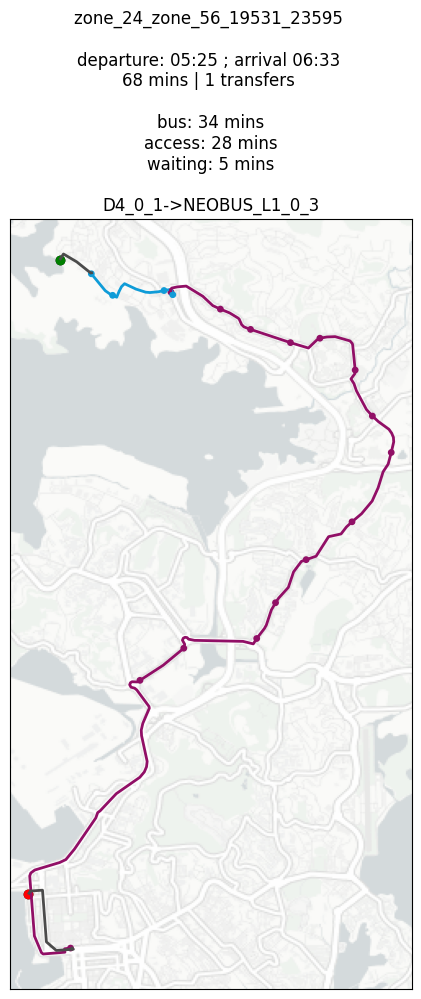

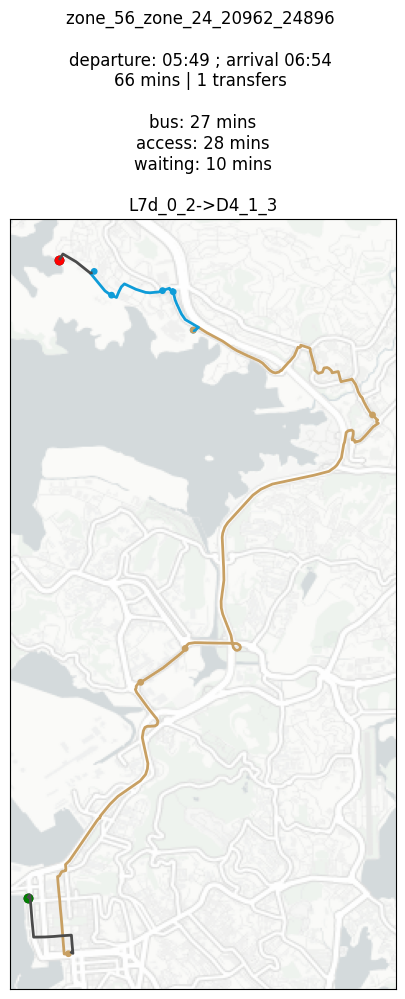

In [276]:
if plot_ODs:
    od_route.to_crs(epsg='4326', inplace=True)
    model = model.change_epsg(epsg='4326', coordinates_unit = 'degree')

    for origin, destination, itinerary_id in pt_los[['origin', 'destination', 'itinerary_id']].values:
        fig, ax = plt.subplots(figsize=(10, 10))
        route = od_route[od_route['itinerary_id'] == itinerary_id]

        route_stations = route.loc[route['type'] == 'link'].copy()
        route_stations = route_stations[['route_color', 'geometry']]
        route_stations['node_from'] = route_stations['geometry'].apply(lambda x: Point(x.coords[0]))
        route_stations['node_to'] = route_stations['geometry'].apply(lambda x: Point(x.coords[-1]))
        route_stations_all = pd.concat([route_stations[['route_color', 'node_from']].rename(columns={'node_from': 'geometry'}), route_stations[['route_color', 'node_to']].rename(columns={'node_to': 'geometry'})])
        route_stations_all = route_stations_all.drop_duplicates()

        model.od_basemap(origin=origin, destination=destination, squared=True, figsize=(10, 10), ax=ax)
        if len(route_stations_all) > 0:
            plot_points(route_stations_all, ax=ax, s=15, color=route_stations_all['route_color'])
        plot_lineStrings(route, ax=ax, linewidth=2, colors=route['route_color'])

        model.zones.loc[[origin]].plot(ax=ax, color='green')
        model.zones.loc[[destination]].plot(ax=ax, color='red')

        create_basemap(ax)

        ax.set_xticks([])
        ax.set_yticks([])

        title = f'{itinerary_id} \n'

        path = pt_los[pt_los['itinerary_id'] == itinerary_id].iloc[0]
        path['min'] = np.round(path['time'] / 60).astype(int)
        mins = (
            (path[time_cols + ['time']] / 60)
            .astype(int)
            .astype(str)
        )
        title += '\n' + 'departure: {}'.format(seconds_time(path['departure_time'])) + ' ; arrival {} \n'.format(seconds_time(path['arrival_time']))
        title += f'{path['min']} mins | {path['ntransfers']} transfers \n'
        for col in time_cols:
            if mins[col] != '0':
                title += '\n' + col.replace('_time', ': ') + mins[col] + ' mins'

        trip_dict = model.links['trip_id'].to_dict()
        trip_list = route['link_path'].apply(trip_dict.get).drop_duplicates().dropna().to_list()
        title += '\n\n'
        title += '->'.join(trip_list)
        ax.set_title(title)

        png = f'OD_PT_{origin}_{destination}.png'
        fig.savefig(os.path.join(output_folder, png), bbox_inches='tight')


In [277]:
print('success')

success


# Bar plot

In [278]:
#import matplotlib.pyplot as plt
#
#systra_colors = [
#    '#74a9cf',
#    '#0570b0',
#    '#bdc9e1',
#    '#b2df8a',
#    '#33a02c',
#    '#fb9a99',
#    '#e31a1c',
#    '#fdbf6f',
#    '#ff7f00',
#    '#cab2d6',
#    '#6a3d9a',
#]
#

In [279]:
# to_plot = pt_los.copy()
# to_plot = to_plot.set_index('itinerary_id')
# to_plot[time_cols] = to_plot[time_cols] / 60

In [280]:
# ax = to_plot[time_cols].plot(kind='barh', stacked=True, figsize=(10, 10), color=systra_colors)
# plt.legend(loc='upper right', ncol=1)
# plt.gca().invert_yaxis()
# plt.xlabel('Time (mins)')
# plt.grid(True, 'major', linestyle='-', axis='both')
# ax.set_axisbelow(True)
# plt.legend(time_cols, loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
# plt.title('Time decomposition for each OD best path')
# plt.savefig(os.path.join(output_folder, 'od_time_decomposition.png'))